In [1]:
!pip install -q pandas numpy httpx matplotlib

In [36]:
# ===== config + imports =====

import os
import re
import json
import time
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import httpx
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------
# paths
# -----------------------------
ARTIFACT_DIR = Path("/content/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

BENCHMARK_BANK_CSV = ARTIFACT_DIR / "benchmark_bank_v1.csv"
BENCHMARK_METADATA_JSON = ARTIFACT_DIR / "benchmark_bank_v1_metadata.json"

# -----------------------------
# output files
# -----------------------------
RESULT_TAG = "thinking_mode_benchmark_v1"

RESULTS_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_results.csv"
RESULTS_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_results.json"

THINKING_ONLY_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_thinking_only_results.csv"
THINKING_ONLY_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_thinking_only_results.json"

NO_THINKING_ONLY_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_no_thinking_only_results.csv"
NO_THINKING_ONLY_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_no_thinking_only_results.json"

SUMMARY_GROUP_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_summary_by_group.csv"
SUMMARY_GROUP_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_summary_by_group.json"

SUMMARY_MODE_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_summary_by_mode.csv"
SUMMARY_MODE_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_summary_by_mode.json"

PAIRWISE_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_pairwise_mode_compare.csv"
PAIRWISE_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_pairwise_mode_compare.json"

SUMMARY_WIDE_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_summary_wide.csv"
SUMMARY_WIDE_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_summary_wide.json"

MODE_SCORES_CSV = ARTIFACT_DIR / f"{RESULT_TAG}_mode_scores.csv"
MODE_SCORES_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_mode_scores.json"

WINNER_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_winner.json"
RUN_METADATA_JSON = ARTIFACT_DIR / f"{RESULT_TAG}_run_metadata.json"

ZIP_ARTIFACT = ARTIFACT_DIR / f"{RESULT_TAG}_artifacts.zip"

# -----------------------------
# scoring
# -----------------------------
FIT_WEIGHT = 0.70

# -----------------------------
# runtime behavior
# -----------------------------
REUSE_EXISTING_THINKING = True
ALWAYS_RERUN_NO_THINKING = True

# -----------------------------
# API
# -----------------------------
required_envs = [
    "OPENROUTER_API_KEY",
]

missing = [k for k in required_envs if not os.getenv(k)]
if missing:
    raise ValueError(
        f"Missing required env vars: {missing}\n"
        "Set them in Colab first, e.g. os.environ['OPENROUTER_API_KEY']='...'"
    )

OPENROUTER_API_KEY = os.environ["OPENROUTER_API_KEY"]
JUDGE_BASE_URL = os.environ.get("JUDGE_BASE_URL", "https://openrouter.ai/api/v1").rstrip("/")
JUDGE_MODEL = os.environ.get("JUDGE_MODEL", "qwen/qwen3.5-35b-a3b")

# -----------------------------
# bootstrap helper:
# if you uploaded old results somewhere else under /content,
# copy them into /content/artifacts automatically.
# -----------------------------
def maybe_bootstrap_existing_results():
    candidate_names = [
        RESULTS_CSV.name,
        THINKING_ONLY_CSV.name,
    ]

    existing_targets = {RESULTS_CSV.resolve(), THINKING_ONLY_CSV.resolve()}

    for name in candidate_names:
        target = ARTIFACT_DIR / name
        if target.exists():
            continue

        matches = []
        for p in Path("/content").rglob(name):
            try:
                rp = p.resolve()
            except Exception:
                continue
            if rp not in existing_targets:
                matches.append(p)

        if matches:
            src = matches[0]
            shutil.copy2(src, target)
            print(f"Imported existing file into artifacts:\n  {src}\n  -> {target}")

maybe_bootstrap_existing_results()

if not BENCHMARK_BANK_CSV.exists():
    raise FileNotFoundError(
        f"Missing benchmark bank: {BENCHMARK_BANK_CSV}\n"
        "Put benchmark_bank_v1.csv inside /content/artifacts first."
    )

print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("BENCHMARK_BANK_CSV:", BENCHMARK_BANK_CSV)
print("BENCHMARK_METADATA_JSON exists:", BENCHMARK_METADATA_JSON.exists())
print("Expected old results path:", RESULTS_CSV)
print("Expected old thinking-only path:", THINKING_ONLY_CSV)
print("JUDGE_BASE_URL:", JUDGE_BASE_URL)
print("JUDGE_MODEL:", JUDGE_MODEL)
print("FIT_WEIGHT:", FIT_WEIGHT)
print("REUSE_EXISTING_THINKING:", REUSE_EXISTING_THINKING)
print("ALWAYS_RERUN_NO_THINKING:", ALWAYS_RERUN_NO_THINKING)

ARTIFACT_DIR: /content/artifacts
BENCHMARK_BANK_CSV: /content/artifacts/benchmark_bank_v1.csv
BENCHMARK_METADATA_JSON exists: True
Expected old results path: /content/artifacts/thinking_mode_benchmark_v1_results.csv
Expected old thinking-only path: /content/artifacts/thinking_mode_benchmark_v1_thinking_only_results.csv
JUDGE_BASE_URL: https://openrouter.ai/api/v1
JUDGE_MODEL: qwen/qwen3.5-35b-a3b
FIT_WEIGHT: 0.7
REUSE_EXISTING_THINKING: True
ALWAYS_RERUN_NO_THINKING: True


In [37]:
# ===== load benchmark bank =====

benchmark_df = pd.read_csv(BENCHMARK_BANK_CSV)

required_cols = [
    "pair_id",
    "group_id",
    "description",
    "poem_text",
    "num_bayts",
]
missing_cols = [c for c in required_cols if c not in benchmark_df.columns]
if missing_cols:
    raise ValueError(f"benchmark_bank_v1.csv is missing columns: {missing_cols}")

benchmark_df = benchmark_df.copy()

optional_defaults = {
    "group_label": None,
    "source_index": -1,
    "description_source_index": -1,
    "poem_source_index": -1,
}
for col, default in optional_defaults.items():
    if col not in benchmark_df.columns:
        benchmark_df[col] = default

benchmark_df["pair_id"] = pd.to_numeric(benchmark_df["pair_id"], errors="coerce").astype(int)
benchmark_df["num_bayts"] = pd.to_numeric(benchmark_df["num_bayts"], errors="coerce").astype(int)
benchmark_df["source_index"] = pd.to_numeric(benchmark_df["source_index"], errors="coerce").fillna(-1).astype(int)
benchmark_df["description_source_index"] = pd.to_numeric(benchmark_df["description_source_index"], errors="coerce").fillna(-1).astype(int)
benchmark_df["poem_source_index"] = pd.to_numeric(benchmark_df["poem_source_index"], errors="coerce").fillna(-1).astype(int)

print("rows =", len(benchmark_df))
print("groups:")
print(benchmark_df["group_id"].value_counts().sort_index())

display(benchmark_df.head(6))

rows = 30
groups:
group_id
group1    10
group2    10
group3    10
Name: count, dtype: int64


,pair_id,group_id,group_label,source_index,description_source_index,poem_source_index,description_meter_label,poem_meter_label,num_bayts,description_num_bayts_row,poem_num_bayts_row,description,poem_text,corruption_note
0,0,group1,group1_original,20181,20181,20181,مخلع البسيط,مخلع البسيط,2,2,2,شكوى مريرة إلى الخالق من ويلاتِ العيشِ المريرة...,أشكو إلى الله من أمورِ\nتمر عيشي لما تمر\nودمل...,original poem + original description
1,0,group2,group2_wrong_description,20181,32667,20181,مجزوء البسيط,مخلع البسيط,2,2,2,مدى تفوق شخصية تُشبه يوسف النبوية لكنها تفوقه ...,أشكو إلى الله من أمورِ\nتمر عيشي لما تمر\nودمل...,description swapped with semantically distant ...
2,0,group3,group3_bad_substance,20181,20181,20181,مخلع البسيط,مخلع البسيط,2,2,2,شكوى مريرة إلى الخالق من ويلاتِ العيشِ المريرة...,شكوى لله من أمور\nالعيش صعب ومرير\nويلات تترسخ...,"same description, selected bad-substance poem"
3,1,group1,group1_original,6083,6083,6083,السريع,السريع,2,2,2,مشهد حزين يُظهر نزاعاً داخلياً بين إنكار الشوق...,تَمَثَّلي إِن شِئتِ في مَنظَرٍ\nيا جولِيا أُنك...,original poem + original description
4,1,group2,group2_wrong_description,6083,73223,6083,الرمل,السريع,2,2,2,دعوة إلى رحمة ربّانية بمواجهة مَن ابتعدوا عن ط...,تَمَثَّلي إِن شِئتِ في مَنظَرٍ\nيا جولِيا أُنك...,description swapped with semantically distant ...
5,1,group3,group3_bad_substance,6083,6083,6083,السريع,السريع,2,2,2,مشهد حزين يُظهر نزاعاً داخلياً بين إنكار الشوق...,اجعلي المشهد حزينًا عامًا\nيا جوليا يظهر إنكار...,"same description, selected bad-substance poem"


In [38]:
# ===== baseline prompt used for mode comparison =====
# keep this stable in this notebook

MEANING_JUDGE_SYSTEM_PROMPT = """
أنتَ محكِّم دلالي دقيق يقيّم قصيدة عربية قياسًا إلى وصفٍ مطلوب.

احكم على بُعدين منفصلين:

1) fit_score
مدى وفاء القصيدة للجوهر الدلالي المركزي في الوصف.

المقصود بالجوهر الدلالي المركزي:
- الموضوع أو الحالة أو الحدث الأساسي،
- العلاقة المحورية بين المتكلم وما يتحدث عنه أو يخاطبه،
- والغرض أو الاتجاه المعنوي العام.

قواعد fit_score:
- لا تطلب مطابقة حرفية.
- لا تعامل الوصف كأنه قائمة تفاصيل يجب استيفاؤها كلها.
- إذا كانت القصيدة قصيرة وكان الوصف أوسع أو أكثر تفسيرًا، فاحكم بحسب مدى التقاط القصيدة لجزء مركزي معتبر من الوصف.
- لا يكفي التشابه العام في الجو أو العاطفة أو بعض الألفاظ لرفع fit_score.
- لا يكفي الاشتراك في موضوع واسع مثل الحزن أو الفخر أو الشكوى أو الجمال إذا اختلف المعنى المركزي أو المقصود الأساسي.
- إذا التقطت القصيدة المرتكزات المحورية والعلاقة الأساسية والغرض العام، فلا تُخفض fit_score بشدة بسبب غياب بعض الطبقات التفسيرية الثانوية في الوصف.
- fit_score المرتفع يتطلب تقاربًا واضحًا في الإطار الدلالي المركزي، لا مجرد شبه عام أو تأويل بعيد.

2) substance_score
مدى كون القصيدة نفسها ذات معنى حقيقي ومقنع، لا مجرد ألفاظ مناسبة ظاهريًا.

قواعد substance_score:
- لا تُخفض الدرجة لمجرد أن القصيدة بسيطة أو مباشرة إذا كان معناها واضحًا.
- اخفض الدرجة عند الفراغ الدلالي، أو التكرار بلا إضافة، أو العمومية الزائدة، أو استعمال ألفاظ موضوعية مرتبطة بالوصف من غير بناء دلالي قوي.
- اخفض الدرجة إذا بدت القصيدة سطحية أو ساذجة أو ضعيفة المعنى، حتى لو كانت قريبة من الموضوع.
- قد تكون القصيدة ذات معنى واضح لكن fit_score فيها منخفض إذا كانت تتحدث عن شيء آخر.

استخدم المجال الكامل من 0 إلى 1.

أخرج JSON فقط، وبالصيغة الدقيقة:
{"fit_score": <number between 0 and 1>, "substance_score": <number between 0 and 1>, "notes": "<brief Arabic justification>"}
""".strip()

MEANING_JUDGE_USER_TEMPLATE = """
قيّم القصيدة قياسًا إلى الوصف، وأخرج درجتين منفصلتين:

- fit_score: مدى توافق القصيدة مع الجوهر الدلالي المركزي في الوصف
- substance_score: مدى كون القصيدة نفسها ذات معنى حقيقي غير فارغ

[الوصف]
{description}

[القصيدة]
{generated_poem}

أخرج JSON فقط.
""".strip()

def build_judge_user_prompt(description, generated_poem):
    return MEANING_JUDGE_USER_TEMPLATE.format(
        description=description,
        generated_poem=generated_poem,
    )

In [39]:
# ===== helpers =====

RESULT_COLUMNS = [
    "mode",
    "pair_id",
    "group_id",
    "group_label",
    "source_index",
    "description_source_index",
    "poem_source_index",
    "num_bayts",
    "description",
    "poem_text",
    "fit_score",
    "substance_score",
    "final_score",
    "latency_sec",
    "notes",
    "error",
    "raw_content",
    "reasoning_tokens",
    "reasoning_present",
    "reasoning_details_present",
    "mode_respected",
    "provider_returned",
    "model_returned",
]

BENCHMARK_INFO_COLS = [
    "pair_id",
    "group_id",
    "group_label",
    "source_index",
    "description_source_index",
    "poem_source_index",
    "num_bayts",
    "description",
    "poem_text",
]

def clamp01(x):
    try:
        x = float(x)
    except Exception:
        x = 0.0
    return max(0.0, min(1.0, x))

def aggregate_meaning_score(fit_score, substance_score, fit_weight=FIT_WEIGHT):
    return fit_weight * fit_score + (1.0 - fit_weight) * substance_score

def df_records_for_json(df):
    clean = df.copy()
    clean = clean.replace({np.nan: None})
    return clean.to_dict(orient="records")

def write_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def save_df_json(df, path):
    write_json(df_records_for_json(df), path)

def extract_content_from_chat_response(data):
    try:
        content = data["choices"][0]["message"]["content"]
    except Exception:
        return ""

    if isinstance(content, str):
        return content

    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, dict):
                if "text" in item:
                    parts.append(str(item["text"]))
                elif "content" in item:
                    parts.append(str(item["content"]))
                else:
                    parts.append(str(item))
            else:
                parts.append(str(item))
        return "\n".join(parts).strip()

    return str(content)

def extract_first_json_object(text):
    text = str(text or "").strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if m:
        candidate = m.group(0)
        try:
            return json.loads(candidate)
        except Exception:
            return {
                "fit_score": 0.0,
                "substance_score": 0.0,
                "notes": "json_parse_failed",
                "raw": text,
            }

    return {
        "fit_score": 0.0,
        "substance_score": 0.0,
        "notes": "json_not_found",
        "raw": text,
    }

def mode_payload_bits(mode):
    if mode == "thinking":
        return {
            "reasoning": {"enabled": True},
            "provider": {
                "require_parameters": True,
                "allow_fallbacks": False,
            },
        }
    elif mode == "no_thinking":
        return {
            "reasoning": {"effort": "none"},
            "provider": {
                "require_parameters": True,
                "allow_fallbacks": False,
            },
        }
    else:
        raise ValueError(f"Unknown mode: {mode}")

def openrouter_chat(mode, system_prompt, user_prompt, timeout=120.0, max_retries=3, backoff_sec=2.0):
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": JUDGE_MODEL,
        "temperature": 0.0,
        "response_format": {"type": "json_object"},
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    }
    payload.update(mode_payload_bits(mode))

    last_err = None
    total_latency = 0.0

    for attempt in range(max_retries + 1):
        t0 = time.time()
        try:
            timeout_obj = httpx.Timeout(timeout, connect=20.0)
            with httpx.Client(timeout=timeout_obj) as client:
                r = client.post(
                    f"{JUDGE_BASE_URL}/chat/completions",
                    headers=headers,
                    json=payload,
                )
                r.raise_for_status()
                data = r.json()

            total_latency += (time.time() - t0)
            return data, total_latency, None

        except (httpx.ReadTimeout, httpx.ConnectTimeout, httpx.TimeoutException, httpx.HTTPError) as e:
            total_latency += (time.time() - t0)
            last_err = f"{type(e).__name__}: {e}"

            if attempt < max_retries:
                print(f"[{mode}] retry {attempt+1}/{max_retries+1} after {last_err}")
                time.sleep(backoff_sec * (attempt + 1))
            else:
                break

    return None, total_latency, last_err

def judge_meaning(mode, description, generated_poem, fit_weight=FIT_WEIGHT):
    user_prompt = build_judge_user_prompt(description, generated_poem)

    raw_data, latency_sec, api_error = openrouter_chat(
        mode=mode,
        system_prompt=MEANING_JUDGE_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        timeout=120.0,
        max_retries=3,
        backoff_sec=2.0,
    )

    if raw_data is None:
        return {
            "fit_score": 0.0,
            "substance_score": 0.0,
            "final_score": 0.0,
            "notes": "api_failed",
            "latency_sec": latency_sec,
            "error": api_error,
            "raw_content": "",
            "reasoning_tokens": None,
            "reasoning_present": None,
            "reasoning_details_present": None,
            "mode_respected": None,
            "provider_returned": None,
            "model_returned": None,
        }

    content = extract_content_from_chat_response(raw_data)
    parsed = extract_first_json_object(content)

    fit_score = clamp01(parsed.get("fit_score", 0.0))
    substance_score = clamp01(parsed.get("substance_score", 0.0))
    final_score = aggregate_meaning_score(fit_score, substance_score, fit_weight=fit_weight)
    notes = str(parsed.get("notes", ""))

    parse_error = None
    if notes in {"json_not_found", "json_parse_failed"}:
        parse_error = notes

    msg = ((raw_data.get("choices") or [{}])[0]).get("message", {}) or {}
    usage = raw_data.get("usage", {}) or {}
    completion_details = usage.get("completion_tokens_details", {}) or {}

    reasoning_tokens = completion_details.get("reasoning_tokens", None)
    reasoning_present = bool(msg.get("reasoning"))
    reasoning_details_present = bool(msg.get("reasoning_details"))

    mode_respected = None
    if mode == "no_thinking":
        mode_respected = (
            (reasoning_tokens == 0)
            and (not reasoning_present)
            and (not reasoning_details_present)
        )

    return {
        "fit_score": fit_score,
        "substance_score": substance_score,
        "final_score": final_score,
        "notes": notes,
        "latency_sec": latency_sec,
        "error": parse_error,
        "raw_content": content,
        "reasoning_tokens": reasoning_tokens,
        "reasoning_present": reasoning_present,
        "reasoning_details_present": reasoning_details_present,
        "mode_respected": mode_respected,
        "provider_returned": raw_data.get("provider"),
        "model_returned": raw_data.get("model"),
    }

def normalize_existing_results_df(df, benchmark_df):
    df = df.copy()

    if "mode" not in df.columns:
        raise ValueError("Existing results CSV has no 'mode' column.")

    # merge benchmark info to backfill missing columns safely
    bench_info = benchmark_df[BENCHMARK_INFO_COLS].drop_duplicates(subset=["pair_id", "group_id"]).copy()
    merged = bench_info.merge(df, on=["pair_id", "group_id"], how="left", suffixes=("_bench", ""))

    for c in BENCHMARK_INFO_COLS:
        if c in ["pair_id", "group_id"]:
            continue
        bench_col = f"{c}_bench"
        if bench_col in merged.columns:
            if c not in merged.columns:
                merged[c] = merged[bench_col]
            else:
                merged[c] = merged[c].where(merged[c].notna(), merged[bench_col])
            merged = merged.drop(columns=[bench_col])

    df = merged.copy()

    default_values = {
        "group_label": None,
        "source_index": -1,
        "description_source_index": -1,
        "poem_source_index": -1,
        "num_bayts": 0,
        "description": "",
        "poem_text": "",
        "fit_score": 0.0,
        "substance_score": 0.0,
        "final_score": 0.0,
        "latency_sec": 0.0,
        "notes": "",
        "error": None,
        "raw_content": "",
        "reasoning_tokens": None,
        "reasoning_present": None,
        "reasoning_details_present": None,
        "mode_respected": None,
        "provider_returned": None,
        "model_returned": None,
    }

    for c, default in default_values.items():
        if c not in df.columns:
            df[c] = default

    int_cols = [
        "pair_id",
        "source_index",
        "description_source_index",
        "poem_source_index",
        "num_bayts",
    ]
    for c in int_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(-1 if c != "num_bayts" else 0).astype(int)

    float_cols = ["fit_score", "substance_score", "final_score", "latency_sec"]
    for c in float_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0).astype(float)

    df["mode"] = df["mode"].astype(str)
    df["group_id"] = df["group_id"].astype(str)
    df["group_label"] = df["group_label"].astype(str)
    df["description"] = df["description"].astype(str)
    df["poem_text"] = df["poem_text"].astype(str)
    df["notes"] = df["notes"].astype(str)
    df["raw_content"] = df["raw_content"].astype(str)

    # recompute final_score to guarantee consistency with current FIT_WEIGHT
    df["final_score"] = [
        aggregate_meaning_score(f, s, fit_weight=FIT_WEIGHT)
        for f, s in zip(df["fit_score"], df["substance_score"])
    ]

    for c in RESULT_COLUMNS:
        if c not in df.columns:
            df[c] = None

    return df[RESULT_COLUMNS].copy()

def benchmark_key_tuples(df):
    return set(zip(df["pair_id"].astype(int), df["group_id"].astype(str)))

def is_complete_for_benchmark(df_mode, benchmark_df):
    bench_keys = benchmark_key_tuples(benchmark_df[["pair_id", "group_id"]].drop_duplicates())
    mode_keys = benchmark_key_tuples(df_mode[["pair_id", "group_id"]].drop_duplicates())
    return bench_keys == mode_keys and len(df_mode) == len(benchmark_df)

def load_reusable_thinking_results(benchmark_df):
    candidate_paths = [THINKING_ONLY_CSV, RESULTS_CSV]

    for p in candidate_paths:
        if not p.exists():
            continue

        try:
            raw = pd.read_csv(p)
        except Exception as e:
            print(f"Could not read existing results from {p}: {e}")
            continue

        if "mode" not in raw.columns:
            if p.name == THINKING_ONLY_CSV.name:
                raw = raw.copy()
                raw["mode"] = "thinking"
            else:
                print(f"Skipping {p}: no 'mode' column.")
                continue

        raw = raw[raw["mode"].astype(str) == "thinking"].copy()
        if len(raw) == 0:
            print(f"Skipping {p}: no thinking rows found.")
            continue

        thinking_df = normalize_existing_results_df(raw, benchmark_df)

        if is_complete_for_benchmark(thinking_df, benchmark_df):
            print(f"Reusing existing thinking results from: {p}")
            return thinking_df, str(p)

        print(f"Found thinking rows in {p}, but coverage is incomplete. Will rerun thinking.")

    return None, None

def run_mode_on_benchmark(mode, benchmark_df, fit_weight=FIT_WEIGHT):
    rows = []

    print("\n" + "#" * 120)
    print(f"RUNNING MODE = {mode}")
    print("#" * 120)

    for idx, row in benchmark_df.iterrows():
        print(
            f"[{mode}] {idx+1}/{len(benchmark_df)} | "
            f"pair={row['pair_id']} | group={row['group_id']} | bayts={row['num_bayts']}"
        )

        res = judge_meaning(
            mode=mode,
            description=row["description"],
            generated_poem=row["poem_text"],
            fit_weight=fit_weight,
        )

        rows.append({
            "mode": mode,
            "pair_id": int(row["pair_id"]),
            "group_id": str(row["group_id"]),
            "group_label": str(row.get("group_label", row["group_id"])),
            "source_index": int(row.get("source_index", -1)),
            "description_source_index": int(row.get("description_source_index", -1)),
            "poem_source_index": int(row.get("poem_source_index", -1)),
            "num_bayts": int(row["num_bayts"]),
            "description": str(row["description"]),
            "poem_text": str(row["poem_text"]),
            "fit_score": float(res["fit_score"]),
            "substance_score": float(res["substance_score"]),
            "final_score": float(res["final_score"]),
            "latency_sec": float(res["latency_sec"]),
            "notes": str(res["notes"]),
            "error": res["error"],
            "raw_content": str(res["raw_content"]),
            "reasoning_tokens": res["reasoning_tokens"],
            "reasoning_present": res["reasoning_present"],
            "reasoning_details_present": res["reasoning_details_present"],
            "mode_respected": res["mode_respected"],
            "provider_returned": res["provider_returned"],
            "model_returned": res["model_returned"],
        })

    out = pd.DataFrame(rows)
    out = normalize_existing_results_df(out, benchmark_df)
    return out

In [40]:
# ===== build clean merged results =====
# logic:
# - reuse old thinking if complete coverage exists
# - otherwise rerun thinking
# - always rerun corrected no_thinking
# - overwrite artifacts with the clean merged outputs

thinking_source = None

thinking_df = None
if REUSE_EXISTING_THINKING:
    thinking_df, thinking_source = load_reusable_thinking_results(benchmark_df)

if thinking_df is None:
    thinking_df = run_mode_on_benchmark("thinking", benchmark_df, fit_weight=FIT_WEIGHT)
    thinking_source = "fresh_run"
else:
    thinking_source = thinking_source or "existing_artifact"

if ALWAYS_RERUN_NO_THINKING:
    no_thinking_df = run_mode_on_benchmark("no_thinking", benchmark_df, fit_weight=FIT_WEIGHT)
    no_thinking_source = "fresh_run"
else:
    no_thinking_df = run_mode_on_benchmark("no_thinking", benchmark_df, fit_weight=FIT_WEIGHT)
    no_thinking_source = "fresh_run"

# save per-mode clean outputs
thinking_df.to_csv(THINKING_ONLY_CSV, index=False, encoding="utf-8-sig")
save_df_json(thinking_df, THINKING_ONLY_JSON)

no_thinking_df.to_csv(NO_THINKING_ONLY_CSV, index=False, encoding="utf-8-sig")
save_df_json(no_thinking_df, NO_THINKING_ONLY_JSON)

# merge clean results
results_df = pd.concat([thinking_df, no_thinking_df], ignore_index=True, sort=False)
results_df = normalize_existing_results_df(results_df, benchmark_df)

mode_order_map = {"thinking": 0, "no_thinking": 1}
group_order_map = {"group1": 0, "group2": 1, "group3": 2}

results_df["_mode_order"] = results_df["mode"].map(mode_order_map).fillna(999)
results_df["_group_order"] = results_df["group_id"].map(group_order_map).fillna(999)
results_df = results_df.sort_values(["_mode_order", "_group_order", "pair_id"]).drop(columns=["_mode_order", "_group_order"]).reset_index(drop=True)

results_df.to_csv(RESULTS_CSV, index=False, encoding="utf-8-sig")
save_df_json(results_df, RESULTS_JSON)

run_metadata = {
    "result_tag": RESULT_TAG,
    "fit_weight": FIT_WEIGHT,
    "judge_model": JUDGE_MODEL,
    "thinking_source": thinking_source,
    "no_thinking_source": no_thinking_source,
    "n_benchmark_rows": int(len(benchmark_df)),
    "n_thinking_rows": int(len(thinking_df)),
    "n_no_thinking_rows": int(len(no_thinking_df)),
    "n_merged_rows": int(len(results_df)),
}
write_json(run_metadata, RUN_METADATA_JSON)

print("saved:", THINKING_ONLY_CSV)
print("saved:", THINKING_ONLY_JSON)
print("saved:", NO_THINKING_ONLY_CSV)
print("saved:", NO_THINKING_ONLY_JSON)
print("saved:", RESULTS_CSV)
print("saved:", RESULTS_JSON)
print("saved:", RUN_METADATA_JSON)

print("\nrun metadata:")
print(json.dumps(run_metadata, ensure_ascii=False, indent=2))

print("\nno_thinking mode_respected counts:")
display(
    no_thinking_df["mode_respected"]
    .value_counts(dropna=False)
    .rename_axis("mode_respected")
    .reset_index(name="count")
)

display(results_df.head(6))

Reusing existing thinking results from: /content/artifacts/thinking_mode_benchmark_v1_results.csv

########################################################################################################################
RUNNING MODE = no_thinking
########################################################################################################################
[no_thinking] 1/30 | pair=0 | group=group1 | bayts=2
[no_thinking] 2/30 | pair=0 | group=group2 | bayts=2
[no_thinking] 3/30 | pair=0 | group=group3 | bayts=2
[no_thinking] 4/30 | pair=1 | group=group1 | bayts=2
[no_thinking] 5/30 | pair=1 | group=group2 | bayts=2
[no_thinking] 6/30 | pair=1 | group=group3 | bayts=2
[no_thinking] 7/30 | pair=2 | group=group1 | bayts=2
[no_thinking] 8/30 | pair=2 | group=group2 | bayts=2
[no_thinking] 9/30 | pair=2 | group=group3 | bayts=2
[no_thinking] 10/30 | pair=3 | group=group1 | bayts=2
[no_thinking] 11/30 | pair=3 | group=group2 | bayts=2
[no_thinking] 12/30 | pair=3 | group=group3 | b

,mode_respected,count
0,True,30


,mode,pair_id,group_id,group_label,source_index,description_source_index,poem_source_index,num_bayts,description,poem_text,...,latency_sec,notes,error,raw_content,reasoning_tokens,reasoning_present,reasoning_details_present,mode_respected,provider_returned,model_returned
0,thinking,0,group1,group1_original,20181,20181,20181,2,شكوى مريرة إلى الخالق من ويلاتِ العيشِ المريرة...,أشكو إلى الله من أمورِ\nتمر عيشي لما تمر\nودمل...,...,27.673375,تلتقط القصيدة جوهر الشكوى لله وصور الليل واليأ...,NaN,"{""fit_score"": 0.75, ""substance_score"": 0.6, ""n...",NaN,NaN,NaN,NaN,NaN,NaN
1,thinking,1,group1,group1_original,6083,6083,6083,2,مشهد حزين يُظهر نزاعاً داخلياً بين إنكار الشوق...,تَمَثَّلي إِن شِئتِ في مَنظَرٍ\nيا جولِيا أُنك...,...,22.354512,تطابق شبه تام مع الوصف في الجوهر الدلالي (جولي...,NaN,"{""fit_score"": 0.95, ""substance_score"": 0.85, ""...",NaN,NaN,NaN,NaN,NaN,NaN
2,thinking,2,group1,group1_original,32667,32667,32667,2,مدى تفوق شخصية تُشبه يوسف النبوية لكنها تفوقه ...,مَلَكتَ رِقّي وَأَنتَ فيهِ\nيا حَسَناً جَلَّ ع...,...,34.375310,القصيدة تلتقط الجوهر الدلالي المركزي (يوسف، ال...,NaN,"{""fit_score"": 0.6, ""substance_score"": 0.7, ""no...",NaN,NaN,NaN,NaN,NaN,NaN
3,thinking,3,group1,group1_original,73223,73223,73223,2,دعوة إلى رحمة ربّانية بمواجهة مَن ابتعدوا عن ط...,من لعميان عدوا نهج الهدى\nولمـوتـى بعد موتـى ي...,...,766.997321,json_not_found,json_not_found,nan,NaN,NaN,NaN,NaN,NaN,NaN
4,thinking,4,group1,group1_original,86244,86244,86244,9,يُشفِّي قلبًا مُنهكًا من صراعٍ بين الاغتراب وا...,يــا مــن يـسـائل عـنـي\nقـد هـجـت عـندي غليلا...,...,100.497576,التوافق الدلالي عالٍ جداً مع تطابق الصور الرئي...,NaN,"{\n ""fit_score"": 0.85,\n ""substance_score"": ...",NaN,NaN,NaN,NaN,NaN,NaN
5,thinking,5,group1,group1_original,67279,67279,67279,5,حملة عسكرية ناجحة تُظهر قوة وفخر الجند، حيث تظ...,جَلَبنَا الخَيلَ مِن كَنَفَي أَريكٍ\nعَـوابِـس...,...,16.845487,الوصف يطابق القصيدة في المحاور الدلالية المركز...,NaN,"{\n ""fit_score"": 0.95,\n ""substance_score"": ...",NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# ===== summaries + save clean CSV/JSON artifacts =====

summary_by_group = (
    results_df
    .groupby(["mode", "group_id"], as_index=False)
    .agg(
        n=("pair_id", "count"),
        fit_mean=("fit_score", "mean"),
        fit_median=("fit_score", "median"),
        substance_mean=("substance_score", "mean"),
        substance_median=("substance_score", "median"),
        final_mean=("final_score", "mean"),
        final_median=("final_score", "median"),
        latency_mean=("latency_sec", "mean"),
        latency_median=("latency_sec", "median"),
        latency_p90=("latency_sec", lambda s: float(np.quantile(s, 0.90))),
        error_count=("error", lambda s: int(pd.Series(s).notna().sum())),
        invalid_mode_count=("mode_respected", lambda s: int((pd.Series(s) == False).sum())),
    )
)

summary_by_mode = (
    results_df
    .groupby(["mode"], as_index=False)
    .agg(
        n=("pair_id", "count"),
        fit_mean=("fit_score", "mean"),
        substance_mean=("substance_score", "mean"),
        final_mean=("final_score", "mean"),
        latency_mean=("latency_sec", "mean"),
        latency_median=("latency_sec", "median"),
        latency_p90=("latency_sec", lambda s: float(np.quantile(s, 0.90))),
        error_count=("error", lambda s: int(pd.Series(s).notna().sum())),
        invalid_mode_count=("mode_respected", lambda s: int((pd.Series(s) == False).sum())),
    )
)

pairwise_compare = (
    results_df
    .pivot_table(
        index=["pair_id", "group_id", "num_bayts"],
        columns="mode",
        values=["fit_score", "substance_score", "final_score", "latency_sec"],
    )
    .reset_index()
)

pairwise_compare.columns = [
    "_".join([str(x) for x in col if str(x) != ""]).strip("_")
    if isinstance(col, tuple) else col
    for col in pairwise_compare.columns
]

if {"final_score_thinking", "final_score_no_thinking"}.issubset(pairwise_compare.columns):
    pairwise_compare["final_gap_thinking_minus_no_thinking"] = (
        pairwise_compare["final_score_thinking"] - pairwise_compare["final_score_no_thinking"]
    )

summary_wide = summary_by_group.pivot(index="group_id", columns="mode", values="final_mean").reset_index()
summary_wide = summary_wide.rename_axis(None, axis=1)
if {"thinking", "no_thinking"}.issubset(summary_wide.columns):
    summary_wide["thinking_minus_no_thinking_final_mean"] = summary_wide["thinking"] - summary_wide["no_thinking"]

summary_by_group.to_csv(SUMMARY_GROUP_CSV, index=False, encoding="utf-8-sig")
save_df_json(summary_by_group, SUMMARY_GROUP_JSON)

summary_by_mode.to_csv(SUMMARY_MODE_CSV, index=False, encoding="utf-8-sig")
save_df_json(summary_by_mode, SUMMARY_MODE_JSON)

pairwise_compare.to_csv(PAIRWISE_CSV, index=False, encoding="utf-8-sig")
save_df_json(pairwise_compare, PAIRWISE_JSON)

summary_wide.to_csv(SUMMARY_WIDE_CSV, index=False, encoding="utf-8-sig")
save_df_json(summary_wide, SUMMARY_WIDE_JSON)

print("saved:", SUMMARY_GROUP_CSV)
print("saved:", SUMMARY_GROUP_JSON)
print("saved:", SUMMARY_MODE_CSV)
print("saved:", SUMMARY_MODE_JSON)
print("saved:", PAIRWISE_CSV)
print("saved:", PAIRWISE_JSON)
print("saved:", SUMMARY_WIDE_CSV)
print("saved:", SUMMARY_WIDE_JSON)

print("\n=== summary_by_group ===")
display(summary_by_group)

print("\n=== summary_by_mode ===")
display(summary_by_mode)

print("\n=== summary_wide ===")
display(summary_wide)

print("\n=== pairwise_compare ===")
display(pairwise_compare.head(10))

saved: /content/artifacts/thinking_mode_benchmark_v1_summary_by_group.csv
saved: /content/artifacts/thinking_mode_benchmark_v1_summary_by_group.json
saved: /content/artifacts/thinking_mode_benchmark_v1_summary_by_mode.csv
saved: /content/artifacts/thinking_mode_benchmark_v1_summary_by_mode.json
saved: /content/artifacts/thinking_mode_benchmark_v1_pairwise_mode_compare.csv
saved: /content/artifacts/thinking_mode_benchmark_v1_pairwise_mode_compare.json
saved: /content/artifacts/thinking_mode_benchmark_v1_summary_wide.csv
saved: /content/artifacts/thinking_mode_benchmark_v1_summary_wide.json

=== summary_by_group ===


,mode,group_id,n,fit_mean,fit_median,substance_mean,substance_median,final_mean,final_median,latency_mean,latency_median,latency_p90,error_count,invalid_mode_count
0,no_thinking,group1,10,0.910,0.950,0.795,0.85,0.8755,0.9200,2.255977,2.162199,2.586586,0,0
1,no_thinking,group2,10,0.165,0.125,0.470,0.40,0.2565,0.2450,2.173611,2.212160,2.499449,0,0
2,no_thinking,group3,10,0.615,0.550,0.310,0.35,0.5235,0.4900,2.061489,2.012849,2.326125,0,0
3,thinking,group1,10,0.770,0.850,0.650,0.65,0.7340,0.7675,110.466928,34.997150,167.147550,1,0
4,thinking,group2,10,0.155,0.100,0.580,0.60,0.2825,0.2650,76.147307,28.257189,97.825128,0,0
5,thinking,group3,10,0.635,0.650,0.315,0.30,0.5390,0.5525,31.943017,26.513511,56.726065,0,0



=== summary_by_mode ===


,mode,n,fit_mean,substance_mean,final_mean,latency_mean,latency_median,latency_p90,error_count,invalid_mode_count
0,no_thinking,30,0.563333,0.525,0.551833,2.163692,2.161417,2.537272,0,0
1,thinking,30,0.520000,0.515,0.518500,72.852418,28.032524,64.912625,1,0



=== summary_wide ===


,group_id,no_thinking,thinking,thinking_minus_no_thinking_final_mean
0,group1,0.8755,0.7340,-0.1415
1,group2,0.2565,0.2825,0.0260
2,group3,0.5235,0.5390,0.0155



=== pairwise_compare ===


,pair_id,group_id,num_bayts,final_score_no_thinking,final_score_thinking,fit_score_no_thinking,fit_score_thinking,latency_sec_no_thinking,latency_sec_thinking,substance_score_no_thinking,substance_score_thinking,final_gap_thinking_minus_no_thinking
0,0,group1,2,0.79,0.705,0.85,0.75,2.272998,27.673375,0.65,0.60,-0.085
1,0,group2,2,0.19,0.220,0.10,0.10,1.641804,21.616713,0.40,0.50,0.030
2,0,group3,2,0.56,0.615,0.65,0.75,2.276962,18.298324,0.35,0.30,0.055
3,1,group1,2,0.92,0.920,0.95,0.95,2.158976,22.354512,0.85,0.85,0.000
4,1,group2,2,0.19,0.250,0.10,0.10,2.534834,22.551398,0.40,0.60,0.060
5,1,group3,2,0.77,0.580,0.95,0.70,2.163859,27.105443,0.35,0.30,-0.190
6,2,group1,2,0.92,0.630,0.95,0.60,2.426210,34.375310,0.85,0.70,-0.290
7,2,group2,2,0.26,0.300,0.20,0.15,1.712608,18.534926,0.40,0.65,0.040
8,2,group3,2,0.37,0.525,0.40,0.60,1.906749,28.305963,0.30,0.35,0.155
9,3,group1,2,0.82,0.000,0.85,0.00,2.149069,766.997321,0.75,0.00,-0.820


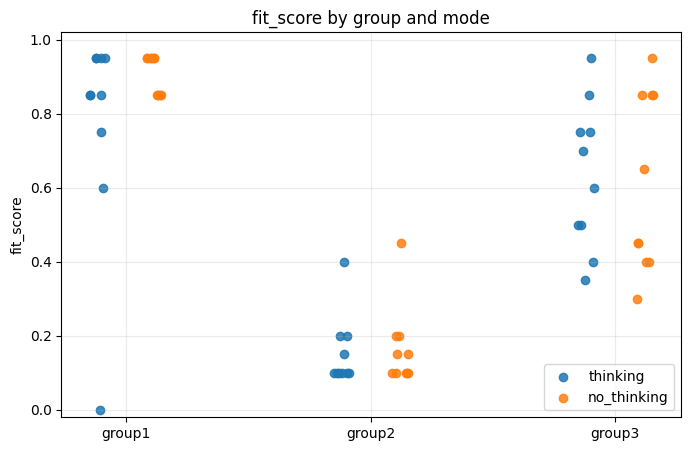

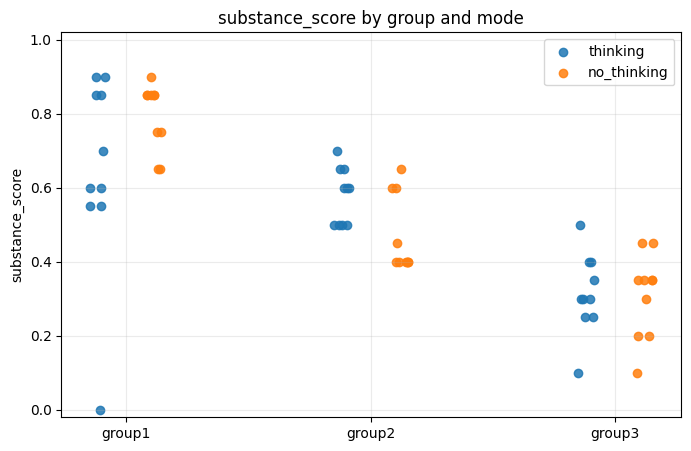

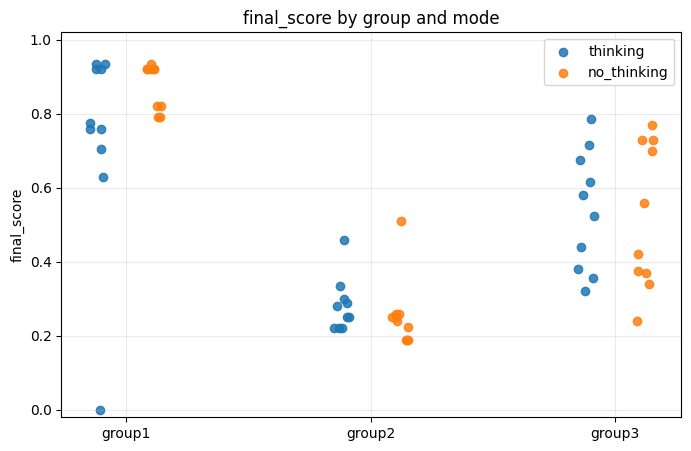

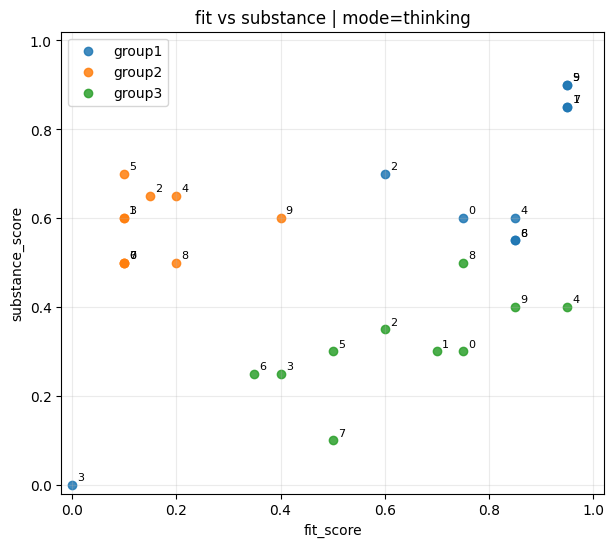

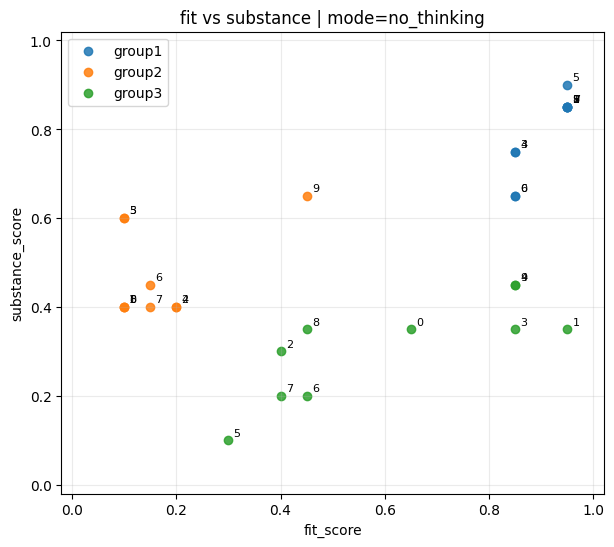

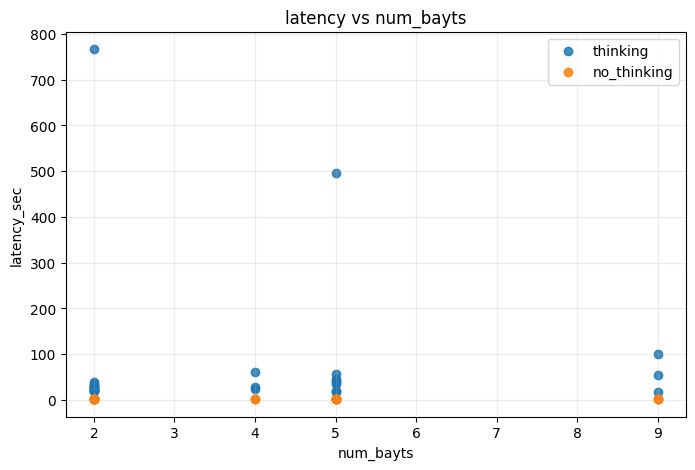

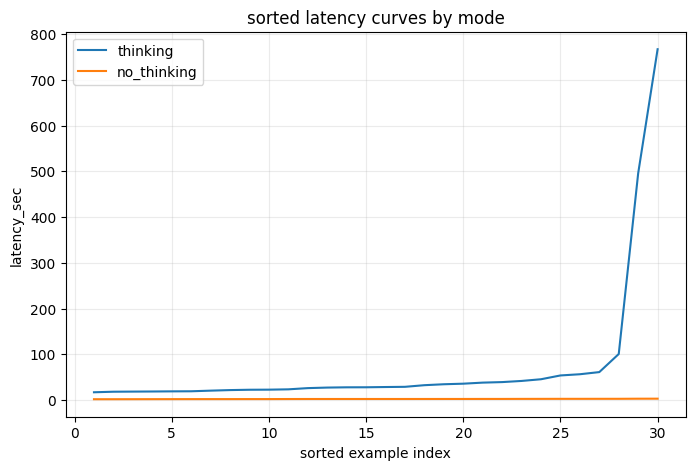

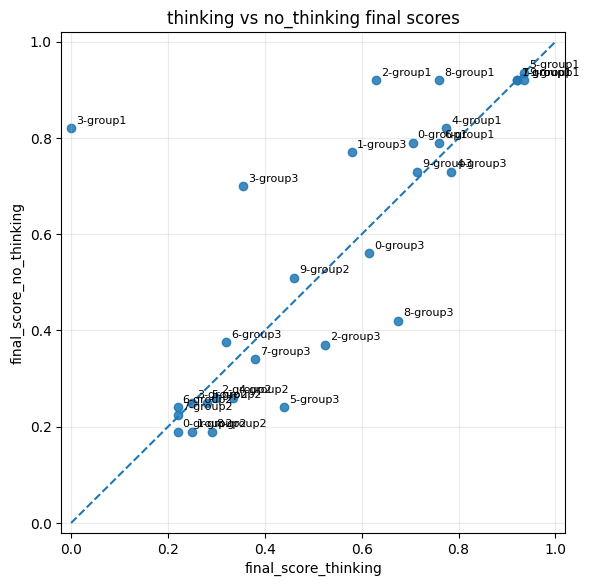

In [42]:
# ===== plotting =====

def jitter(values, amount=0.06, seed=42):
    rng = np.random.default_rng(seed)
    return np.array(values) + rng.uniform(-amount, amount, size=len(values))

group_order = ["group1", "group2", "group3"]
mode_order = ["thinking", "no_thinking"]
metric_order = ["fit_score", "substance_score", "final_score"]

group_to_x = {g: i for i, g in enumerate(group_order)}

def plot_jittered_metric(metric):
    fig, ax = plt.subplots(figsize=(8, 5))

    for mode_idx, mode in enumerate(mode_order):
        sub = results_df[results_df["mode"] == mode].copy()
        xs = [group_to_x[g] + (-0.12 if mode == "thinking" else 0.12) for g in sub["group_id"]]
        xs = jitter(xs, amount=0.035, seed=42 + mode_idx)
        ax.scatter(xs, sub[metric].values, alpha=0.85, label=mode)

    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by group and mode")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

for metric in metric_order:
    plot_jittered_metric(metric)

for mode in mode_order:
    sub = results_df[results_df["mode"] == mode].copy()

    fig, ax = plt.subplots(figsize=(7, 6))
    for group_id in group_order:
        g = sub[sub["group_id"] == group_id]
        ax.scatter(g["fit_score"], g["substance_score"], alpha=0.85, label=group_id)

        for _, r in g.iterrows():
            ax.text(
                r["fit_score"] + 0.01,
                r["substance_score"] + 0.01,
                f"{int(r['pair_id'])}",
                fontsize=8,
            )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("fit_score")
    ax.set_ylabel("substance_score")
    ax.set_title(f"fit vs substance | mode={mode}")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for mode in mode_order:
    sub = results_df[results_df["mode"] == mode].copy()
    ax.scatter(sub["num_bayts"], sub["latency_sec"], alpha=0.85, label=mode)

ax.set_xlabel("num_bayts")
ax.set_ylabel("latency_sec")
ax.set_title("latency vs num_bayts")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for mode in mode_order:
    vals = np.sort(results_df[results_df["mode"] == mode]["latency_sec"].values)
    ax.plot(np.arange(1, len(vals) + 1), vals, label=mode)

ax.set_xlabel("sorted example index")
ax.set_ylabel("latency_sec")
ax.set_title("sorted latency curves by mode")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

tmp = pairwise_compare.dropna(subset=["final_score_thinking", "final_score_no_thinking"]).copy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(tmp["final_score_thinking"], tmp["final_score_no_thinking"], alpha=0.85)

for _, r in tmp.iterrows():
    ax.text(
        r["final_score_thinking"] + 0.01,
        r["final_score_no_thinking"] + 0.01,
        f"{int(r['pair_id'])}-{r['group_id']}",
        fontsize=8,
    )

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("final_score_thinking")
ax.set_ylabel("final_score_no_thinking")
ax.set_title("thinking vs no_thinking final scores")
ax.grid(True, alpha=0.25)
plt.show()

In [43]:
# ===== failure slices =====

def show_slice(df_local, title, n=3):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)

    cols = [
        "mode",
        "pair_id",
        "group_id",
        "num_bayts",
        "fit_score",
        "substance_score",
        "final_score",
        "latency_sec",
        "notes",
        "error",
        "reasoning_tokens",
        "mode_respected",
        "description",
        "poem_text",
    ]
    display(df_local[cols].head(n))

for mode in mode_order:
    sub = results_df[results_df["mode"] == mode].copy()

    show_slice(
        sub[sub["group_id"] == "group1"].sort_values("final_score", ascending=True),
        title=f"{mode} | lowest group1 final_score",
        n=3,
    )

    show_slice(
        sub[sub["group_id"] == "group2"].sort_values("fit_score", ascending=False),
        title=f"{mode} | highest group2 fit_score",
        n=3,
    )

    show_slice(
        sub[sub["group_id"] == "group3"].sort_values("substance_score", ascending=False),
        title=f"{mode} | highest group3 substance_score",
        n=3,
    )

    show_slice(
        sub[sub["group_id"] == "group3"].sort_values("fit_score", ascending=False),
        title=f"{mode} | highest group3 fit_score",
        n=3,
    )


thinking | lowest group1 final_score


,mode,pair_id,group_id,num_bayts,fit_score,substance_score,final_score,latency_sec,notes,error,reasoning_tokens,mode_respected,description,poem_text
3,thinking,3,group1,2,0.00,0.0,0.000,766.997321,json_not_found,json_not_found,NaN,NaN,دعوة إلى رحمة ربّانية بمواجهة مَن ابتعدوا عن ط...,من لعميان عدوا نهج الهدى\nولمـوتـى بعد موتـى ي...
2,thinking,2,group1,2,0.60,0.7,0.630,34.375310,القصيدة تلتقط الجوهر الدلالي المركزي (يوسف، ال...,NaN,NaN,NaN,مدى تفوق شخصية تُشبه يوسف النبوية لكنها تفوقه ...,مَلَكتَ رِقّي وَأَنتَ فيهِ\nيا حَسَناً جَلَّ ع...
0,thinking,0,group1,2,0.75,0.6,0.705,27.673375,تلتقط القصيدة جوهر الشكوى لله وصور الليل واليأ...,NaN,NaN,NaN,شكوى مريرة إلى الخالق من ويلاتِ العيشِ المريرة...,أشكو إلى الله من أمورِ\nتمر عيشي لما تمر\nودمل...



thinking | highest group2 fit_score


,mode,pair_id,group_id,num_bayts,fit_score,substance_score,final_score,latency_sec,notes,error,reasoning_tokens,mode_respected,description,poem_text
19,thinking,9,group2,4,0.4,0.60,0.460,28.755292,تلتقط القصيدة صور الإرهاق والشوق الجسدي والروح...,NaN,NaN,NaN,يُشفِّي قلبًا مُنهكًا من صراعٍ بين الاغتراب وا...,وَشَخصٍ طَيِّبِ الأَردا\nنِ لا تَعرِفُ أَمثالَ...
14,thinking,4,group2,9,0.2,0.65,0.335,53.618926,التوافق الدلالي ضعيف جدًا؛ فالوصف يطلب تكريمًا...,NaN,NaN,NaN,وصف مباشر: \nيُبرز المحتوى تكريمًا لشخصية شري...,يــا مــن يـسـائل عـنـي\nقـد هـجـت عـندي غليلا...
18,thinking,8,group2,5,0.2,0.50,0.290,495.680954,الوصف يركز على الانتصار العسكري وفخر الجنود، ب...,NaN,NaN,NaN,حملة عسكرية ناجحة تُظهر قوة وفخر الجند، حيث تظ...,وَقَوْرَاءَ مِنْ قَوْسِ الْغَمَامِ ابْتَغُوا ل...



thinking | highest group3 substance_score


...

,mode,pair_id,group_id,num_bayts,fit_score,substance_score,final_score,latency_sec,notes,error,reasoning_tokens,mode_respected,description,poem_text
49,no_thinking,9,group2,4,0.45,0.65,0.51,2.490399,تتوافق القصيدة جزئيًا مع جوهر الوصف عبر صور ال...,None,0.0,True,يُشفِّي قلبًا مُنهكًا من صراعٍ بين الاغتراب وا...,وَشَخصٍ طَيِّبِ الأَردا\nنِ لا تَعرِفُ أَمثالَ...
42,no_thinking,2,group2,2,0.20,0.40,0.26,1.712608,الوصف يطلب شكوى مريرة من ويلات العيش، مع صور ل...,None,0.0,True,شكوى مريرة إلى الخالق من ويلاتِ العيشِ المريرة...,مَلَكتَ رِقّي وَأَنتَ فيهِ\nيا حَسَناً جَلَّ ع...
44,no_thinking,4,group2,9,0.20,0.40,0.26,1.913182,لا تتوافق القصيدة مع الجوهر الدلالي للوصف؛ فال...,None,0.0,True,وصف مباشر: \nيُبرز المحتوى تكريمًا لشخصية شري...,يــا مــن يـسـائل عـنـي\nقـد هـجـت عـندي غليلا...



no_thinking | highest group3 substance_score


,mode,pair_id,group_id,num_bayts,fit_score,substance_score,final_score,latency_sec,notes,error,reasoning_tokens,mode_respected,description,poem_text
59,no_thinking,9,group3,4,0.85,0.45,0.73,1.952658,تلتقط القصيدة الجوهر الدلالي المركزي بدقة عالي...,None,0.0,True,رجلٌ ذو خلقٍ نادرٍ يعاني من جوعٍ يُبكيهِ مع حُ...,هذا رجل ذو خلق نادر ويعاني\nمن جوع يبكيه وجوع ...
54,no_thinking,4,group3,9,0.85,0.45,0.73,1.790050,تتوافق القصيدة بقوة مع الجوهر الدلالي للوصف من...,None,0.0,True,يُشفِّي قلبًا مُنهكًا من صراعٍ بين الاغتراب وا...,يا من يخبر عني وعن حالي\nقد صرت قلباً منهكاً ف...
51,no_thinking,1,group3,2,0.95,0.35,0.77,2.163859,تتطابق القصيدة تطابقًا شبه تام مع الجوهر الدلا...,None,0.0,True,مشهد حزين يُظهر نزاعاً داخلياً بين إنكار الشوق...,اجعلي المشهد حزينًا عامًا\nيا جوليا يظهر إنكار...



no_thinking | highest group3 fit_score


,mode,pair_id,group_id,num_bayts,fit_score,substance_score,final_score,latency_sec,notes,error,reasoning_tokens,mode_respected,description,poem_text
51,no_thinking,1,group3,2,0.95,0.35,0.77,2.163859,تتطابق القصيدة تطابقًا شبه تام مع الجوهر الدلا...,None,0.0,True,مشهد حزين يُظهر نزاعاً داخلياً بين إنكار الشوق...,اجعلي المشهد حزينًا عامًا\nيا جوليا يظهر إنكار...
53,no_thinking,3,group3,2,0.85,0.35,0.70,1.654127,تتوافق القصيدة دلاليًا مع جوهر الوصف (دعوة للر...,None,0.0,True,دعوة إلى رحمة ربّانية بمواجهة مَن ابتعدوا عن ط...,دعوة للرحمة في طريق الحق\nوالرحمة للذين ابتعدو...
59,no_thinking,9,group3,4,0.85,0.45,0.73,1.952658,تلتقط القصيدة الجوهر الدلالي المركزي بدقة عالي...,None,0.0,True,رجلٌ ذو خلقٍ نادرٍ يعاني من جوعٍ يُبكيهِ مع حُ...,هذا رجل ذو خلق نادر ويعاني\nمن جوع يبكيه وجوع ...


In [44]:
# ===== choose winner + save winner artifacts =====

def get_group_metric(mode, group_id, col):
    return float(summary_by_group.query("mode == @mode and group_id == @group_id")[col].iloc[0])

def get_mode_metric(mode, col):
    return float(summary_by_mode.query("mode == @mode")[col].iloc[0])

group1_t = get_group_metric("thinking", "group1", "final_mean")
group2_t = get_group_metric("thinking", "group2", "final_mean")
group3_t = get_group_metric("thinking", "group3", "final_mean")

group1_n = get_group_metric("no_thinking", "group1", "final_mean")
group2_n = get_group_metric("no_thinking", "group2", "final_mean")
group3_n = get_group_metric("no_thinking", "group3", "final_mean")

g3_sub_t = get_group_metric("thinking", "group3", "substance_mean")
g3_sub_n = get_group_metric("no_thinking", "group3", "substance_mean")

lat_med_t = get_mode_metric("thinking", "latency_median")
lat_med_n = get_mode_metric("no_thinking", "latency_median")

lat_p90_t = get_mode_metric("thinking", "latency_p90")
lat_p90_n = get_mode_metric("no_thinking", "latency_p90")

err_t = int(get_mode_metric("thinking", "error_count"))
err_n = int(get_mode_metric("no_thinking", "error_count"))

invalid_t = int(get_mode_metric("thinking", "invalid_mode_count"))
invalid_n = int(get_mode_metric("no_thinking", "invalid_mode_count"))

mode_scores = pd.DataFrame([
    {
        "mode": "thinking",
        "group1_minus_group2": group1_t - group2_t,
        "group1_minus_group3": group1_t - group3_t,
        "group3_substance_mean": g3_sub_t,
        "latency_median": lat_med_t,
        "latency_p90": lat_p90_t,
        "error_count": err_t,
        "invalid_mode_count": invalid_t,
    },
    {
        "mode": "no_thinking",
        "group1_minus_group2": group1_n - group2_n,
        "group1_minus_group3": group1_n - group3_n,
        "group3_substance_mean": g3_sub_n,
        "latency_median": lat_med_n,
        "latency_p90": lat_p90_n,
        "error_count": err_n,
        "invalid_mode_count": invalid_n,
    },
])

display(mode_scores)

thinking_score = (
    2.0 * (group1_t - group2_t) +
    1.0 * (group1_t - group3_t) -
    0.8 * g3_sub_t -
    0.020 * lat_med_t -
    0.008 * lat_p90_t -
    0.40 * err_t
)

no_thinking_score = (
    2.0 * (group1_n - group2_n) +
    1.0 * (group1_n - group3_n) -
    0.8 * g3_sub_n -
    0.020 * lat_med_n -
    0.008 * lat_p90_n -
    0.40 * err_n -
    1.50 * invalid_n
)

winner = "thinking" if thinking_score >= no_thinking_score else "no_thinking"

winner_payload = {
    "winner": winner,
    "thinking_score": float(thinking_score),
    "no_thinking_score": float(no_thinking_score),
    "fit_weight": float(FIT_WEIGHT),
    "judge_model": JUDGE_MODEL,
    "thinking_source": thinking_source,
    "invalid_no_thinking_count": int(invalid_n),
}

mode_scores.to_csv(MODE_SCORES_CSV, index=False, encoding="utf-8-sig")
save_df_json(mode_scores, MODE_SCORES_JSON)
write_json(winner_payload, WINNER_JSON)

print("saved:", MODE_SCORES_CSV)
print("saved:", MODE_SCORES_JSON)
print("saved:", WINNER_JSON)

print(json.dumps(winner_payload, ensure_ascii=False, indent=2))

,mode,group1_minus_group2,group1_minus_group3,group3_substance_mean,latency_median,latency_p90,error_count,invalid_mode_count
0,thinking,0.4515,0.195,0.315,28.032524,64.912625,1,0
1,no_thinking,0.6190,0.352,0.310,2.161417,2.537272,0,0


saved: /content/artifacts/thinking_mode_benchmark_v1_mode_scores.csv
saved: /content/artifacts/thinking_mode_benchmark_v1_mode_scores.json
saved: /content/artifacts/thinking_mode_benchmark_v1_winner.json
{
  "winner": "no_thinking",
  "thinking_score": -0.6339514858245856,
  "no_thinking_score": 1.2784734753608702,
  "fit_weight": 0.7,
  "judge_model": "qwen/qwen3.5-35b-a3b",
  "thinking_source": "/content/artifacts/thinking_mode_benchmark_v1_results.csv",
  "invalid_no_thinking_count": 0
}


In [45]:
# ===== package and download all clean artifacts =====

from google.colab import files

paths_to_bundle = [
    THINKING_ONLY_CSV,
    THINKING_ONLY_JSON,
    NO_THINKING_ONLY_CSV,
    NO_THINKING_ONLY_JSON,
    RESULTS_CSV,
    RESULTS_JSON,
    SUMMARY_GROUP_CSV,
    SUMMARY_GROUP_JSON,
    SUMMARY_MODE_CSV,
    SUMMARY_MODE_JSON,
    PAIRWISE_CSV,
    PAIRWISE_JSON,
    SUMMARY_WIDE_CSV,
    SUMMARY_WIDE_JSON,
    MODE_SCORES_CSV,
    MODE_SCORES_JSON,
    WINNER_JSON,
    RUN_METADATA_JSON,
]

with zipfile.ZipFile(ZIP_ARTIFACT, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in paths_to_bundle:
        if p.exists():
            zf.write(p, arcname=p.name)
        else:
            print("missing, skipped:", p)

print("zip ready:", ZIP_ARTIFACT)

print("\ncontents:")
with zipfile.ZipFile(ZIP_ARTIFACT, "r") as zf:
    for name in zf.namelist():
        print(" -", name)

files.download(str(ZIP_ARTIFACT))

zip ready: /content/artifacts/thinking_mode_benchmark_v1_artifacts.zip

contents:
 - thinking_mode_benchmark_v1_thinking_only_results.csv
 - thinking_mode_benchmark_v1_thinking_only_results.json
 - thinking_mode_benchmark_v1_no_thinking_only_results.csv
 - thinking_mode_benchmark_v1_no_thinking_only_results.json
 - thinking_mode_benchmark_v1_results.csv
 - thinking_mode_benchmark_v1_results.json
 - thinking_mode_benchmark_v1_summary_by_group.csv
 - thinking_mode_benchmark_v1_summary_by_group.json
 - thinking_mode_benchmark_v1_summary_by_mode.csv
 - thinking_mode_benchmark_v1_summary_by_mode.json
 - thinking_mode_benchmark_v1_pairwise_mode_compare.csv
 - thinking_mode_benchmark_v1_pairwise_mode_compare.json
 - thinking_mode_benchmark_v1_summary_wide.csv
 - thinking_mode_benchmark_v1_summary_wide.json
 - thinking_mode_benchmark_v1_mode_scores.csv
 - thinking_mode_benchmark_v1_mode_scores.json
 - thinking_mode_benchmark_v1_winner.json
 - thinking_mode_benchmark_v1_run_metadata.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>